In [ ]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import os
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

import pandas as pd

import wandb

from copy import deepcopy

from cmcrameri import cm


# Configure matplotlib to use LaTeX for r'' strings while keeping other text unchanged
mpl.rcParams.update({
    'text.usetex': True,          # Use LaTeX for r'' strings
    'font.family': 'sans-serif',  # Default font family for regular text
    'mathtext.fontset': 'dejavusans',  # Font for math not using r''
    'axes.formatter.use_mathtext': False  # Enable math text for tick labels
})

In [2]:
# set random seed
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(42)

In [ ]:
from plot_utils import extract_all_results, results_to_dataframe, \
    plot_advanced_comparison, method_names, method_colors, true_var_names, \
    performances_to_dataframe, visualize_projections, visualize_3d_projections, \
    plot_sin_cos_vs_theta, plot_variable_vs_true

from readout_utils import compute_readout_projections

In [ ]:
from harpl.networks.utils import additional_data_process, prepare_model
from harpl.scripts.utils import (
    get_data_specs,
    prepare_data,
)

from harpl.networks.networks import LinearReadout

In [6]:
api = wandb.Api()

In [ ]:
savedir = 'RPL_figures/2_moving_animals'
if not os.path.exists(savedir):
    os.makedirs(savedir)

## Uncorrected orientation readouts (show accuracy plots read from wandb)

In [ ]:
datasets = ["animals_cts_noiseOnTop0.1",]
dataset_to_plot = 'animals_cts_noiseOnTop0.1'

method_map = {
    'sup': 'supervised',
    'rand': 'random',
    'pred': 'pred',
    'inv_sg': 'inv_sg',
    'pred-mem': 'pred_ctx_target',
    'invZ': 'invZ',
    'invC': 'invC',
    'inv_sg_nr': 'inv_sg_nr'
}

# Extract results with both accuracy and r2 metrics
results = extract_all_results(datasets=datasets, method_map=method_map, wandb_project="RPL", remove_offline=True)

# Convert to DataFrame
results_df = results_to_dataframe(results)

No exact match found for method_key: omega_pred_ctx_target
No exact match found for method_key: omega_pred_ctx_target
No exact match found for method_key: omega_pred_ctx_target
No exact match found for method_key: omega_inv_sg
No exact match found for method_key: omega_inv_sg
No exact match found for method_key: omega_inv_sg
No exact match found for method_key: omega_pred
No exact match found for method_key: omega_pred
No exact match found for method_key: omega_pred
No exact match found for method_key: omega_random
No exact match found for method_key: omega_supervised
No exact match found for method_key: invZnr
No exact match found for method_key: invZnr
No exact match found for method_key: invZnr
Processed 20 runs
Found accuracy metrics in 20 runs
Found R2 metrics in 20 runs


In [9]:
methods = ['pred', 'pred-mem', 'inv_sg', 'invZ', 'invC', 'inv_sg_nr']
for method in methods:
    print(f"Method: {method}")
    # Get sprite ID accuracy with std dev
    sprite_acc = results_df[(results_df['method'] == method) & (results_df['task'] == 'sprite_idx')]['accuracy']
    sprite_acc_mean = sprite_acc.mean()
    sprite_acc_std = sprite_acc.std()
    print(f"Sprite ID Accuracy: {sprite_acc_mean:.4f} ± {sprite_acc_std:.4f}")
    
    rotation_speed_r2 = results_df[(results_df['method'] == method) & (results_df['task'] == 'rotation_speed')]['r2']
    rotation_speed_r2_mean = rotation_speed_r2.mean()
    rotation_speed_r2_std = rotation_speed_r2.std()
    print(f"Rotation Speed R2: {rotation_speed_r2_mean:.4f} ± {rotation_speed_r2_std:.4f}")

Method: pred
Sprite ID Accuracy: 1.0000 ± 0.0000
Rotation Speed R2: 0.9483 ± 0.0376
Method: pred-mem
Sprite ID Accuracy: 0.9904 ± 0.0166
Rotation Speed R2: 0.0119 ± 0.0040
Method: inv_sg
Sprite ID Accuracy: 0.9917 ± 0.0144
Rotation Speed R2: 0.0129 ± 0.0023
Method: invZ
Sprite ID Accuracy: 0.8619 ± 0.0037
Rotation Speed R2: 0.0034 ± 0.0050
Method: invC
Sprite ID Accuracy: 0.8745 ± 0.0096
Rotation Speed R2: 0.0210 ± 0.0055
Method: inv_sg_nr
Sprite ID Accuracy: 0.1275 ± 0.0000
Rotation Speed R2: -0.0057 ± 0.0000


In [10]:
method = 'pred'
dataset = dataset_to_plot
print(f"Method: {method} on {dataset}")

# Filter dataframe for the specific dataset and method
df_filtered = results_df[(results_df['dataset'] == dataset) & (results_df['method'] == method)]

# Get all tasks for this dataset and method
tasks = df_filtered['task'].unique()

# Print metrics for each task
for task in sorted(tasks):
    task_data = df_filtered[df_filtered['task'] == task]
    
    # Check if there's accuracy data for this task
    if not task_data['accuracy'].isna().all():
        acc_mean = task_data['accuracy'].mean()
        acc_std = task_data['accuracy'].std()
        print(f"Task: {task} - Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
    
    # Check if there's R2 data for this task
    if not task_data['r2'].isna().all():
        r2_mean = task_data['r2'].mean()
        r2_std = task_data['r2'].std()
        print(f"Task: {task} - R2: {r2_mean:.4f} ± {r2_std:.4f}")

Method: pred on animals_cts_fixTest_noiseOnTop0.1
Task: cos - R2: 0.5918 ± 0.0106
Task: orientation - Accuracy: 0.2238 ± 0.0233
Task: rotation_direction - Accuracy: 0.7996 ± 0.1338
Task: rotation_speed - R2: 0.9483 ± 0.0376
Task: sin - R2: 0.6234 ± 0.0351
Task: speed - R2: 0.9611 ± 0.0012
Task: sprite_idx - Accuracy: 1.0000 ± 0.0000
Task: x-direction - Accuracy: 0.9631 ± 0.0036
Task: x-position - R2: 0.9939 ± 0.0006
Task: x-position  - Accuracy: 0.8328 ± 0.0014
Task: x-velocity - R2: 0.8972 ± 0.0065
Task: y-direction - Accuracy: 0.9632 ± 0.0026
Task: y-position - R2: 0.9946 ± 0.0011
Task: y-position  - Accuracy: 0.8291 ± 0.0047
Task: y-velocity - R2: 0.8940 ± 0.0086
Task: z-direction - Accuracy: 0.9451 ± 0.0050
Task: z-position - R2: 0.9862 ± 0.0023
Task: z-position  - Accuracy: 0.6992 ± 0.0195
Task: z-velocity - R2: 0.8427 ± 0.0072


In [11]:
mpl.rc('text', usetex=True)
mpl.rc('text.latex', preamble=r'\usepackage{amsmath}')

In [ ]:
# Define your metric configurations
metric_configs = {
    'accuracy': {
        'individual_tasks': {
            'sprite_idx': r'$S$',
        },
        'averaged_tasks': []
    },
    'r2': {
        'individual_tasks': {},
        'averaged_tasks': [
            {
                'tasks': ['x-position', 'y-position', 'z-position'],
                'name': r'$\boldsymbol{r}$'
            },
            {
                'tasks': ['x-velocity', 'y-velocity', 'z-velocity'],
                'name': r'$\boldsymbol{v}$'
            },
            {
                'tasks': ['sin', 'cos'],
                'name': r'$\boldsymbol{\theta}$'
            },
            {
                'tasks': ['rotation_speed'],
                'name': r'$|\omega|$'
            },
        ],
    }
}

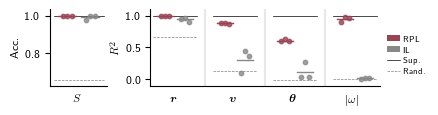

In [ ]:
# Create the plot
fig, axes = plot_advanced_comparison(
    results_df=results_df,
    methods_to_plot=['pred', 'inv_sg'],
    baseline_methods=['sup', 'rand'],
    metric_configs=metric_configs,
    method_names=method_names,
    method_colors=method_colors,
    dataset=dataset_to_plot,
    figsize=(4.25, 1.0),
    plot_spacing=0.3,
    point_size=10,
    sharey=True,
    loc_legend=(1.02, 0.1),
)

## Dataloaders and model loading

In [ ]:
input_size, num_classes = get_data_specs(dataset="animals",
                                        target_label="multitask",
                                        dsprites_seqtype="full",
                                        flatten_images=False,
                                        spritevid_num_sprites=8)

(train_loader, train_sampler, 
    val_loader, val_sampler,
        test_loader, test_sampler,
    ) = prepare_data(
            dataset="animals",
            data_input_dir="../datasets",
            seq_len=32,
            num_workers=0,
            batch_size=128,
            val_batch_size=128,
            grayscale=False,
            target_label="multitask",
            spritevid_max_sprites=8,
            spritevid_noise_type="gaussian",
            spritevid_noise_level=0.1,
            spritevid_discretize_latents=False,
            sprite_noise_on_top=True,
        )

Computing normalization values using 10000 samples...
Computed normalization values - mean: tensor([0.5009, 0.4961, 0.4950], device='cuda:0'), std: tensor([0.1234, 0.1192, 0.1209], device='cuda:0')


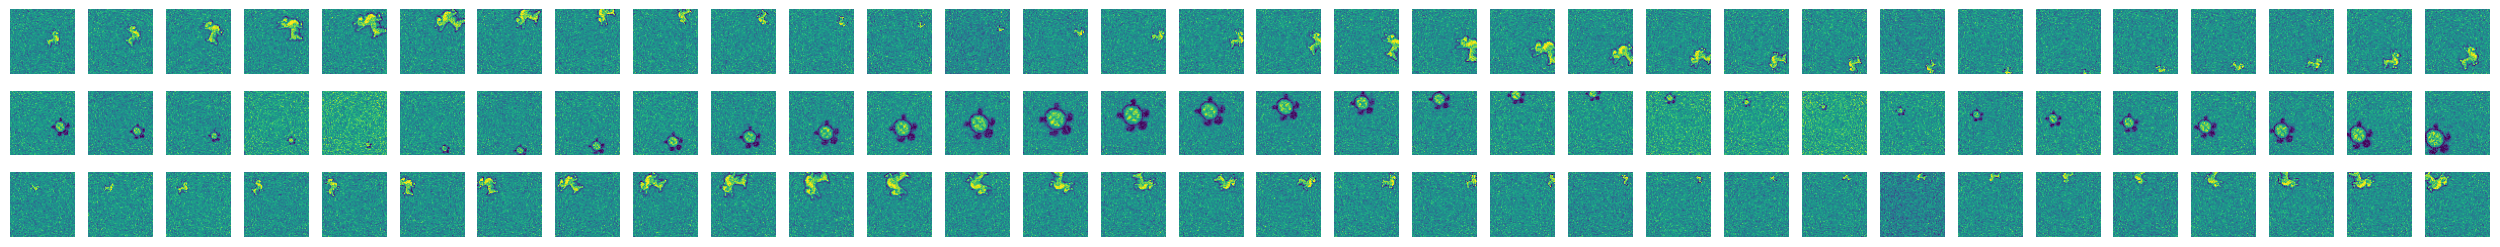

In [15]:
# show the first 3 videos of 32 frames each (64x64 grayscale images)
data, labels = next(iter(train_loader))

# show images in data_samples (selected 3 samples each a sequence of 16 64x64 images)
samples_to_plot = [2, 4, 8]

data_samples_to_plot = data[samples_to_plot].detach().cpu().numpy()

fig, ax = plt.subplots(3, 32, figsize=(32, 3))

for i in range(len(samples_to_plot)):
    for j in range(32):
        ax[i, j].imshow(data_samples_to_plot[i, j, 0])
        ax[i, j].axis('off')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model_dir = '../checkpoints'

In [ ]:
preprocess, postprocess = additional_data_process("animals", flatten_enc_output=True)
n_in_channels = 3

In [ ]:
random_model = deepcopy(prepare_model(
    encoder_kind="conv2d",
    integrator_kind="lstm",
    predictor_kind="mlp",
    input_size=input_size,
    n_in_channels=n_in_channels,
    enc_dim=32,
    ctx_dim=512,
    pred_n_hidden_layers=1,
    pred_hidden_dim=512,
    pred_steps=1,
    prediction_target="enc",
    use_bn_enc=True,
    enc_n_layers=6,
    enc_kernel_size=[(5, 5)] * 6,
    enc_stride=[(2, 2)] * 2 + [(1, 1)] * 4,
    enc_padding=[(2, 2)] * 6,
    preprocess=preprocess,
    postprocess=postprocess,
    flatten_enc_output=True,
    return_full_features=True,
    state_dict=torch.load(os.path.join(model_dir, "animals_cts_noiseOnTop0.1_random_1/model_final.pt")),
)).to(device)

supervised_model = deepcopy(prepare_model(
    encoder_kind="conv2d",
    integrator_kind="lstm",
    predictor_kind="mlp",
    input_size=input_size,
    n_in_channels=n_in_channels,
    enc_dim=32,
    ctx_dim=512,
    pred_n_hidden_layers=1,
    pred_hidden_dim=512,
    pred_steps=1,
    prediction_target="enc",
    use_bn_enc=True,
    enc_n_layers=6,
    enc_kernel_size=[(5, 5)] * 6,
    enc_stride=[(2, 2)] * 2 + [(1, 1)] * 4,
    enc_padding=[(2, 2)] * 6,
    preprocess=preprocess,
    postprocess=postprocess,
    flatten_enc_output=True,
    return_full_features=True,
    state_dict=torch.load(os.path.join(model_dir, "animals_cts_noiseOnTop0.1_supervised_1/model_final.pt")),
)).to(device)

In [ ]:
pred_model_dirs = [f"animals_cts_noiseOnTop0.1_pred_{i}" for i in range(1, 4)]

inv_model_dirs = [f"animals_cts_noiseOnTop0.1_inv_sg_{i}" for i in range(1, 4)]

In [ ]:
pred_models = []
for i in range(len(pred_model_dirs)):
    pred_model = deepcopy(prepare_model(
        encoder_kind="conv2d",
        integrator_kind="lstm",
        predictor_kind="mlp",
        input_size=input_size,
        n_in_channels=n_in_channels,
        enc_dim=32,
        ctx_dim=512,
        pred_n_hidden_layers=1,
        pred_hidden_dim=512,
        pred_steps=1,
        prediction_target="enc",
        use_bn_enc=True,
        enc_n_layers=6,
        enc_kernel_size=[(5, 5)] * 6,
        enc_stride=[(2, 2)] * 2 + [(1, 1)] * 4,
        enc_padding=[(2, 2)] * 6,
        preprocess=preprocess,
        postprocess=postprocess,
        flatten_enc_output=True,
        return_full_features=True,
        state_dict=torch.load(os.path.join(model_dir, pred_model_dirs[i], "model_final.pt"))
    )).to(device)
    print("RPL model created")
    pred_models.append(pred_model)

inv_models = []
for i in range(len(inv_model_dirs)):
    inv_model = deepcopy(prepare_model(
        encoder_kind="conv2d",
        integrator_kind="lstm",
        predictor_kind="mlp",
        input_size=input_size,
        enc_dim=32,
        ctx_dim=512,
        pred_n_hidden_layers=1,
        pred_hidden_dim=512,
        pred_steps=1,
        prediction_target="pred",
        use_bn_enc=True,
        enc_n_layers=6,
        enc_kernel_size=[(5, 5)] * 6,
        enc_stride=[(2, 2)] * 2 + [(1, 1)] * 4,
        enc_padding=[(2, 2)] * 6,
        preprocess=preprocess,
        postprocess=postprocess,
        n_in_channels=n_in_channels,
        flatten_enc_output=True,
        return_full_features=True,
        state_dict=torch.load(os.path.join(model_dir, inv_model_dirs[i], "model_final.pt"))
    )).to(device)
    print("IL model created")
    inv_models.append(inv_model)

Model created
Model created
Model created
IL model created
IL model created
IL model created


In [22]:
def prepare_readout(readout_input_dim, num_classes):
    readout = nn.ModuleList()
    num_classes_seq_labels = num_classes[0]
    if num_classes_seq_labels is not None:
        for task_name in num_classes_seq_labels.keys():
            readout.append(LinearReadout(num_classes=num_classes_seq_labels[task_name], input_dim=readout_input_dim,
                                            seq_len=32, concat_over_time=False, task_name=task_name,
                                            concat_over_batch=False))
    num_classes_dense_labels = num_classes[1]
    if num_classes_dense_labels is not None:
        for task_name in num_classes_dense_labels.keys():
            readout.append(LinearReadout(num_classes=num_classes_dense_labels[task_name], input_dim=readout_input_dim,
                                            seq_len=32, concat_over_time=False, task_name=task_name,
                                            concat_over_batch=True))
    num_seq_regr_targets = num_classes[2]
    if num_seq_regr_targets is not None:
        for task_name in num_seq_regr_targets.keys():
            readout.append(LinearReadout(num_classes=num_seq_regr_targets[task_name], input_dim=readout_input_dim,
                                            seq_len=32, concat_over_time=False, task_name=task_name,
                                            concat_over_batch=False))
    num_dense_regr_targets = num_classes[3]
    if num_dense_regr_targets is not None:
        for task_name in num_dense_regr_targets.keys():
            readout.append(LinearReadout(num_classes=num_dense_regr_targets[task_name], input_dim=readout_input_dim,
                                            seq_len=32, concat_over_time=False, task_name=task_name,
                                            concat_over_batch=True))
    
    return readout

In [23]:
readout_input_dim = inv_model.integrator.backbone.weight_ih_l0.shape[0] // 4

pred_readouts = [
    prepare_readout(readout_input_dim, num_classes=num_classes).to(device) \
        for i in range(len(pred_models))
]
inv_readouts = [
    prepare_readout(readout_input_dim, num_classes=num_classes).to(device) \
        for i in range(len(inv_models))
]
random_readout = prepare_readout(readout_input_dim, num_classes=num_classes).to(device)
supervised_readout = prepare_readout(readout_input_dim, num_classes=num_classes).to(device)

In [ ]:
for i in range(len(pred_models)):
    pred_readouts[i].load_state_dict(torch.load(os.path.join(model_dir, pred_model_dirs[i], "offline_ctx_readout.pt")))

for i in range(len(inv_models)):
    inv_readouts[i].load_state_dict(torch.load(os.path.join(model_dir, inv_model_dirs[i], "offline_ctx_readout.pt")))

random_readout.load_state_dict(torch.load(os.path.join(model_dir, "animals_cts_noiseOnTop0.1_random_1", "offline_ctx_readout.pt")))
supervised_readout.load_state_dict(torch.load(os.path.join(model_dir, "animals_cts_noiseOnTop0.1_supervised_1", "offline_ctx_readout.pt")))

<All keys matched successfully>

In [ ]:
pred_readout_train_mean_list = []
pred_readout_train_std_list = []
for i in range(len(pred_models)):
    pred_i_readout_stats = torch.load(os.path.join(model_dir, pred_model_dirs[i], "offline_ctx_readout_stats.pt"))
    pred_readout_train_mean_list.append(pred_i_readout_stats["mean"].to(device))
    pred_readout_train_std_list.append(pred_i_readout_stats["std"].to(device))

inv_readout_train_mean_list = []
inv_readout_train_std_list = []
for i in range(len(inv_models)):
    inv_i_readout_stats = torch.load(os.path.join(model_dir, inv_model_dirs[i], "offline_ctx_readout_stats.pt"))
    inv_readout_train_mean_list.append(inv_i_readout_stats["mean"].to(device))
    inv_readout_train_std_list.append(inv_i_readout_stats["std"].to(device))

random_readout_train_stats = torch.load(os.path.join(model_dir, "animals_cts_noiseOnTop0.1_random_1", "offline_ctx_readout_stats.pt"))
random_readout_train_mean = random_readout_train_stats["mean"].to(device)
random_readout_train_std = random_readout_train_stats["std"].to(device)

supervised_readout_train_stats = torch.load(os.path.join(model_dir, "animals_cts_noiseOnTop0.1_supervised_1", "offline_ctx_readout_stats.pt"))
supervised_readout_train_mean = supervised_readout_train_stats["mean"].to(device)
supervised_readout_train_std = supervised_readout_train_stats["std"].to(device)

In [26]:
num_classes

({'sprite_idx': 8, 'rotation_direction': 3},
 {'x-direction': 3,
  'y-direction': 3,
  'z-direction': 3,
  'x-position (discr)': 33,
  'y-position (discr)': 33,
  'z-position (discr)': 17,
  'orientation': 36},
 {'speed': 1, 'rotation_speed': 1},
 {'x-position': 1,
  'y-position': 1,
  'z-position': 1,
  'x-velocity': 1,
  'y-velocity': 1,
  'z-velocity': 1,
  'sin': 1,
  'cos': 1})

## Orientation corrections (per-class phase shifts)
Skip this section if you have run the notebook once.

In [27]:
class_idxes = [0, 7]

In [27]:
pred_projections_list = []
pred_latent_labels_list = []
pred_performance_list = []
pred_phase_shifts_list = []
pred_corrected_readout_list = []

for i in range(len(pred_models)):
    print(f"Computing projections for model {i+1}/{len(pred_models)}")
    pred_projections, pred_latent_labels, pred_performance, pred_phase_shifts, pred_corrected_readout = compute_readout_projections(
        model=pred_models[i],
        readouts=pred_readouts[i],
        train_loader=train_loader,
        data_loader=test_loader,
        device=device,
        readout_input_mean_train=pred_readout_train_mean_list[i],
        readout_input_std_train=pred_readout_train_std_list[i],
        num_classes=num_classes,
        class_idxes=class_idxes
    )
    
    pred_projections_list.append(pred_projections)
    pred_latent_labels_list.append(pred_latent_labels)
    pred_performance_list.append(pred_performance)
    pred_phase_shifts_list.append(pred_phase_shifts)
    pred_corrected_readout_list.append(pred_corrected_readout)

Computing projections for model 1/3


Corrected Orientation Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Binary Classifier Training (Classes 0 vs 7):   0%|          | 0/400 [00:00<?, ?it/s]

Computing projections for model 2/3


Corrected Orientation Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Binary Classifier Training (Classes 0 vs 7):   0%|          | 0/400 [00:00<?, ?it/s]

Computing projections for model 3/3


Corrected Orientation Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Binary Classifier Training (Classes 0 vs 7):   0%|          | 0/400 [00:00<?, ?it/s]

In [28]:
inv_projections_list = []
inv_latent_labels_list = []
inv_performance_list = []
inv_phase_shifts_list = []
inv_corrected_readout_list = []
for i in range(len(inv_models)):
    print(f"Computing projections for model {i+1}/{len(inv_models)}")
    inv_projections, inv_latent_labels, inv_performance, inv_phase_shifts, inv_corrected_readout = compute_readout_projections(
        model=inv_models[i],
        readouts=inv_readouts[i],
        train_loader=train_loader,
        data_loader=test_loader,
        device=device,
        readout_input_mean_train=inv_readout_train_mean_list[i],
        readout_input_std_train=inv_readout_train_std_list[i],
        num_classes=num_classes,
        class_idxes=class_idxes
    )
    
    inv_projections_list.append(inv_projections)
    inv_latent_labels_list.append(inv_latent_labels)
    inv_performance_list.append(inv_performance)
    inv_phase_shifts_list.append(inv_phase_shifts)
    inv_corrected_readout_list.append(inv_corrected_readout)

Computing projections for model 1/3


Corrected Orientation Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Binary Classifier Training (Classes 0 vs 7):   0%|          | 0/400 [00:00<?, ?it/s]

Computing projections for model 2/3


Corrected Orientation Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Binary Classifier Training (Classes 0 vs 7):   0%|          | 0/400 [00:00<?, ?it/s]

Computing projections for model 3/3


Corrected Orientation Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Binary Classifier Training (Classes 0 vs 7):   0%|          | 0/400 [00:00<?, ?it/s]

In [29]:
random_projections, random_latent_labels, random_performance, random_phase_shifts, random_readout_corrected = compute_readout_projections(
    model=random_model,
    readouts=random_readout,
    device=device,
    readout_input_mean_train=random_readout_train_mean,
    readout_input_std_train=random_readout_train_std,
    data_loader=test_loader,
    num_classes=num_classes,
    train_loader=train_loader,
    class_idxes=class_idxes
)
print(random_performance[-2])
print(random_phase_shifts)

supervised_projections, supervised_latent_labels, supervised_performance, supervised_phase_shifts, supervised_readout_corrected = compute_readout_projections(
    model=supervised_model,
    readouts=supervised_readout,
    device=device,
    readout_input_mean_train=supervised_readout_train_mean,
    readout_input_std_train=supervised_readout_train_std,
    data_loader=test_loader,
    num_classes=num_classes,
    train_loader=train_loader,
    class_idxes=class_idxes
)
print(supervised_performance[-2])
print(supervised_phase_shifts)

Corrected Orientation Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Binary Classifier Training (Classes 0 vs 7):   0%|          | 0/400 [00:00<?, ?it/s]

{'sin': 0.0008661067539822431, 'cos': -0.0004716436504677013, 'theta_discr': 0.03112399193548387}
tensor([-0.5097, -0.7803,  0.5536, -0.1843, -3.0347,  0.5420,  0.8695, -0.7414],
       device='cuda:1')


Corrected Orientation Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Binary Classifier Training (Classes 0 vs 7):   0%|          | 0/400 [00:00<?, ?it/s]

{'sin': 0.9988726614614807, 'cos': 0.9987207755258134, 'theta_discr': 0.8711961315524194}
tensor([-0.0082, -0.0088, -0.0078, -0.0076, -0.0077, -0.0081, -0.0079, -0.0082],
       device='cuda:1')


In [30]:
pred_performance_list[0][-2], inv_performance_list[0][-2], random_performance[-2], supervised_performance[-2]

({'sin': 0.7872819097940117,
  'cos': 0.7823150248085141,
  'theta_discr': 0.4588268649193548},
 {'sin': 0.2938286630232758,
  'cos': 0.31527734293876963,
  'theta_discr': 0.1307648689516129},
 {'sin': 0.0008661067539822431,
  'cos': -0.0004716436504677013,
  'theta_discr': 0.03112399193548387},
 {'sin': 0.9988726614614807,
  'cos': 0.9987207755258134,
  'theta_discr': 0.8711961315524194})

In [31]:
pred_performance_list[0][-1], inv_performance_list[0][-1], random_performance[-1], supervised_performance[-1]

({'bin': 0.9999686479568481},
 {'bin': 0.9995298385620117},
 {'bin': 0.6141549944877625},
 {'bin': 0.993699848651886})

In [32]:
method_names

{'sup': 'Sup.',
 'rand': 'Rand.',
 'raw': 'Pixel',
 'pred': 'RPL',
 'inv_sg': 'IL',
 'inv_sg_nr': '$\\text{IL}^{\\text{nr}}$',
 'pred-mem': 'CL',
 'invZ': '$\\text{IL}^z$',
 'invC': '$\\text{IL}^c$'}

In [58]:
# save all projections
torch.save({
    'pred_projections_list': pred_projections_list,
    'pred_latent_labels_list': pred_latent_labels_list,
    'pred_performance_list': pred_performance_list,
    'pred_phase_shifts_list': pred_phase_shifts_list,
    'pred_corrected_readout_list': pred_corrected_readout_list,
    'inv_projections_list': inv_projections_list,
    'inv_latent_labels_list': inv_latent_labels_list,
    'inv_performance_list': inv_performance_list,
    'inv_phase_shifts_list': inv_phase_shifts_list,
    'inv_corrected_readout_list': inv_corrected_readout_list,
    'random_projections': random_projections,
    'random_latent_labels': random_latent_labels,
    'random_performance': random_performance,
    'random_phase_shifts': random_phase_shifts,
    'random_readout_corrected': random_readout_corrected,
    'supervised_projections': supervised_projections,
    'supervised_latent_labels': supervised_latent_labels,
    'supervised_performance': supervised_performance,
    'supervised_phase_shifts': supervised_phase_shifts,
    'supervised_readout_corrected': supervised_readout_corrected
}, os.path.join(savedir, 'animals_cts_latents_projections_corrected.pt'))

## Plot comparison plots with phase-corrected orientation results

In [28]:
all_projections = torch.load(os.path.join(savedir, 'animals_cts_latents_projections_corrected.pt'))
pred_projections_list = all_projections['pred_projections_list']
pred_latent_labels_list = all_projections['pred_latent_labels_list']
pred_performance_list = all_projections['pred_performance_list']
pred_phase_shifts_list = all_projections['pred_phase_shifts_list']
pred_corrected_readout_list = all_projections['pred_corrected_readout_list']
inv_projections_list = all_projections['inv_projections_list']
inv_latent_labels_list = all_projections['inv_latent_labels_list']
inv_performance_list = all_projections['inv_performance_list']
inv_phase_shifts_list = all_projections['inv_phase_shifts_list']
inv_corrected_readout_list = all_projections['inv_corrected_readout_list']
random_projections = all_projections['random_projections']
random_latent_labels = all_projections['random_latent_labels']
random_performance = all_projections['random_performance']
random_phase_shifts = all_projections['random_phase_shifts']
random_readout_corrected = all_projections['random_readout_corrected']
supervised_projections = all_projections['supervised_projections']
supervised_latent_labels = all_projections['supervised_latent_labels']
supervised_performance = all_projections['supervised_performance']
supervised_phase_shifts = all_projections['supervised_phase_shifts']
supervised_readout_corrected = all_projections['supervised_readout_corrected']

In [ ]:
# Define your metric configurations
metric_configs = {
    'accuracy': {
        'individual_tasks': {
            'sprite_idx': r'$S$',
        },
        'averaged_tasks': []
    },
    'r2': {
        'individual_tasks': {},
        'averaged_tasks': [
            {
                'tasks': ['x-position', 'y-position', 'z-position'],
                'name': r'$\boldsymbol{r}$'
            },
            {
                'tasks': ['x-velocity', 'y-velocity', 'z-velocity'],
                'name': r'$\boldsymbol{v}$'
            },
            {
                'tasks': ['sin_corrected', 'cos_corrected'],
                'name': r'$\boldsymbol{\theta}$'
            },
            {
                'tasks': ['rotation_speed'],
                'name': r'$|\omega|$'
            },
        ],
    }
}

                              dataset  method                   task  seed  \
0   animals_cts_fixTest_noiseOnTop0.1    pred             sprite_idx     0   
1   animals_cts_fixTest_noiseOnTop0.1    pred     rotation_direction     0   
2   animals_cts_fixTest_noiseOnTop0.1    pred            x-direction     0   
3   animals_cts_fixTest_noiseOnTop0.1    pred            y-direction     0   
4   animals_cts_fixTest_noiseOnTop0.1    pred            z-direction     0   
5   animals_cts_fixTest_noiseOnTop0.1    pred     x-position (discr)     0   
6   animals_cts_fixTest_noiseOnTop0.1    pred     y-position (discr)     0   
7   animals_cts_fixTest_noiseOnTop0.1    pred     z-position (discr)     0   
8   animals_cts_fixTest_noiseOnTop0.1    pred            orientation     0   
9   animals_cts_fixTest_noiseOnTop0.1    pred                  speed     0   
10  animals_cts_fixTest_noiseOnTop0.1    pred         rotation_speed     0   
11  animals_cts_fixTest_noiseOnTop0.1    pred             x-posi

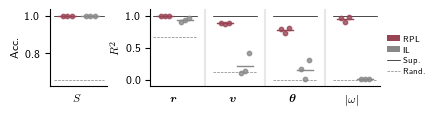

In [ ]:
# Combine the performances into a single dictionary
method_performances = {
    'rand': random_performance,
    'sup': supervised_performance
}

# Convert to DataFrame
results_df = performances_to_dataframe(method_performances, dataset_name=dataset_to_plot)

for i in range(len(pred_performance_list)):
    method_performances = {
        'pred': pred_performance_list[i],
        'inv_sg': inv_performance_list[i]
    }
    df = performances_to_dataframe(method_performances, dataset_name=dataset_to_plot, seed=i)
    print(df)
    results_df = pd.concat([results_df, df], ignore_index=True)

# Now you can use this with plot_advanced_comparison
fig, axes = plot_advanced_comparison(
    results_df=results_df,
    methods_to_plot=['pred', 'inv_sg'],
    baseline_methods=['sup', 'rand'],
    metric_configs=metric_configs,
    method_names=method_names,
    method_colors=method_colors,
    dataset=dataset_to_plot,
    figsize=(4.25, 1.0),
    plot_spacing=0.3,
    point_size=10,
    sharey=True,
    loc_legend=(1.02, 0.1),
)

fig.savefig(os.path.join(savedir, 'animals_cts_fixTest_noiseOnTop0.1_comparison_corrected.pdf'), bbox_inches='tight', transparent=True, dpi=300)

# Plot cosine similarity of coding directions for dynamic variables

In [ ]:
# Compute ordinary least squares linear regression for all models
from harpl.scripts.eval_utils import offline_linear_regression

pred_lin_reg_results = []
for i in range(len(pred_models)):
    print(f"Computing linear regression for model {i+1}/{len(pred_models)}")
    pred_lin_reg_result = offline_linear_regression(
        train_dataloader=train_loader,
        test_dataloader=test_loader,
        model=pred_models[i],
        downstream_input="ctx",
        num_classes=num_classes,
        device=device,
    )
    pred_lin_reg_results.append(pred_lin_reg_result)

inv_lin_reg_results = []
for i in range(len(inv_models)):
    print(f"Computing linear regression for model {i+1}/{len(inv_models)}")
    inv_lin_reg_result = offline_linear_regression(
        train_dataloader=train_loader,
        test_dataloader=test_loader,
        model=inv_models[i],
        downstream_input="ctx",
        num_classes=num_classes,
        device=device,
    )
    inv_lin_reg_results.append(inv_lin_reg_result)

supervised_lin_reg_result = offline_linear_regression(
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    model=supervised_model,
    downstream_input="ctx",
    num_classes=num_classes,
    device=device,
)

random_lin_reg_result = offline_linear_regression(
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    model=random_model,
    downstream_input="ctx",
    num_classes=num_classes,
    device=device,
)

Computing linear regression for model 1/3
Computing linear regression for model 2/3
Computing linear regression for model 3/3
Computing linear regression for model 1/3
Computing linear regression for model 2/3
Computing linear regression for model 3/3


In [ ]:
# Extract dense regressor weights for all models
pred_dense_reg_weights = [pred_lin_reg_results[i]["dense_regressor"].coef_ for i in range(len(pred_lin_reg_results))]
inv_dense_reg_weights = [inv_lin_reg_results[i]["dense_regressor"].coef_ for i in range(len(inv_lin_reg_results))]
supervised_dense_reg_weights = supervised_lin_reg_result["dense_regressor"].coef_
random_dense_reg_weights = random_lin_reg_result["dense_regressor"].coef_

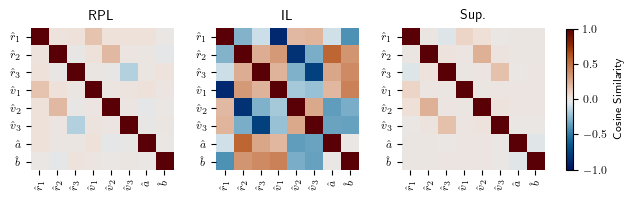

In [ ]:
# Compute pairwise cosine similarity between the weights of the dense regressors
from sklearn.metrics.pairwise import cosine_similarity

cos_sim_pred = [cosine_similarity(pred_dense_reg_weights[i]) for i in range(len(pred_dense_reg_weights))]
cos_sim_inv = [cosine_similarity(inv_dense_reg_weights[i]) for i in range(len(inv_dense_reg_weights))]
cos_sim_sup = cosine_similarity(supervised_dense_reg_weights)
cos_sim_rand = cosine_similarity(random_dense_reg_weights)

labels = [r'$\hat{r}_1$', r'$\hat{r}_2$', r'$\hat{r}_3$', r'$\hat{v}_1$', r'$\hat{v}_2$', r'$\hat{v}_3$', r'$\hat{a}$', r'$\hat{b}$']

# plot the cosine similarity matrices
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
axes[0].imshow(np.mean(cos_sim_pred, axis=0), vmin=-1, vmax=1, cmap=cm.vik)  # average over different models
axes[0].set_title('RPL', fontsize=10)
axes[1].imshow(np.mean(cos_sim_inv, axis=0), vmin=-1, vmax=1, cmap=cm.vik)  # average over different models
axes[1].set_title('IL', fontsize=10)
axes[2].imshow(cos_sim_sup, vmin=-1, vmax=1, cmap=cm.vik)
axes[2].set_title('Sup.', fontsize=10)
for ax in axes:
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, rotation=0)
    ax.set_xticklabels(labels, rotation=90)
    ax.spines[:].set_visible(False)
# increase space between subplots
plt.subplots_adjust(wspace=0.3)
# add colorbar to the right of the subplots
cbar = fig.colorbar(axes[2].images[0], ax=axes, orientation='vertical', fraction=0.013, pad=0.04)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Cosine Similarity', rotation=90, labelpad=5, fontsize=8)
fig.savefig(os.path.join(savedir, 'cosine_similarity_heatmaps.pdf'), bbox_inches='tight', transparent=True, dpi=300)

## Projection scatter plots

In [ ]:
colormap = cm.lipari

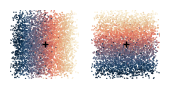

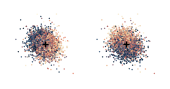

In [ ]:
fig_2d_pred = visualize_projections(
    projections_data=pred_projections_list[0],
    labels_data=pred_latent_labels_list[0],
    simple_mode=True,                  # use the simplified single-row layout
    colormap=colormap,                # change colormap
    show_colorbar=False,
    true_var_names=true_var_names,
    plot_indices=[2, 3],
    xlim=(-1.2, 1.2),
    ylim=(-1.2, 1.2),
    scale_bar=False,
    figsize=(2.0, 0.9),
)

fig_2d_inv = visualize_projections(
    projections_data=inv_projections_list[0],
    labels_data=inv_latent_labels_list[0],
    simple_mode=True,                  # use the simplified single-row layout
    colormap=colormap,                # change colormap
    show_colorbar=False,
    true_var_names=true_var_names,
    plot_indices=[2, 3],
    xlim=(-1.2, 1.2),
    ylim=(-1.2, 1.2),
    scale_bar=True,
    figsize=(2.0, 0.9),
)

# save the figure
fig_2d_pred.savefig(os.path.join(savedir, 'pred_vel_projections.png'), dpi=300, bbox_inches='tight', transparent=True)
fig_2d_inv.savefig(os.path.join(savedir, 'inv_vel_projections.png'), dpi=300, bbox_inches='tight', transparent=True)

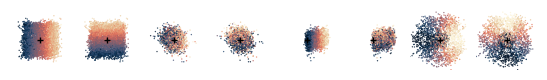

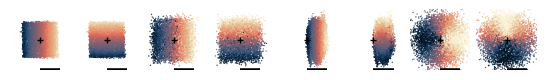

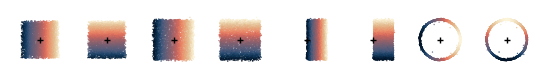

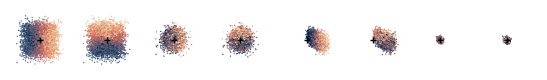

In [ ]:
xlim = (-1.5, 1.5)
ylim = (-1.5, 1.5)

suppl_fig_panel_inv = visualize_projections(
    projections_data=inv_projections_list[0],
    labels_data=inv_latent_labels_list[0],
    simple_mode=True,                  # use the simplified single-row layout
    colormap=colormap,                # change colormap
    show_colorbar=False,
    true_var_names=true_var_names,
    figsize=(6.8, 1.0),
    save_path=os.path.join(savedir, 'full_inv_projections.png'),
    xlim=xlim,
    ylim=ylim,
)

suppl_fig_panel_pred = visualize_projections(
    projections_data=pred_projections_list[0],
    labels_data=pred_latent_labels_list[0],
    simple_mode=True,                  # use the simplified single-row layout
    colormap=colormap,                # change colormap
    show_colorbar=False,
    true_var_names=true_var_names,
    figsize=(6.8, 1.0),
    save_path=os.path.join(savedir, 'full_pred_projections.png'),
    xlim=xlim,
    ylim=ylim,
    scale_bar=True
)

suppl_fig_panel_supervised = visualize_projections(
    projections_data=supervised_projections,
    labels_data=supervised_latent_labels,
    simple_mode=True,                  # use the simplified single-row layout
    colormap=colormap,                # change colormap
    show_colorbar=False,
    true_var_names=true_var_names,
    figsize=(6.8, 1.0),
    save_path=os.path.join(savedir, 'full_supervised_projections.png'),
    xlim=xlim,
    ylim=ylim,
)

suppl_fig_panel_random = visualize_projections(
    projections_data=random_projections,
    labels_data=random_latent_labels,
    simple_mode=True,                  # use the simplified single-row layout
    colormap=colormap,                # change colormap
    show_colorbar=False,
    true_var_names=true_var_names,
    figsize=(6.8, 1.0),
    save_path=os.path.join(savedir, 'full_random_projections.png'),
    xlim=xlim,
    ylim=ylim,
)

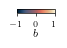

In [93]:
val_range = np.array([[-1, 1]])
plt.figure(figsize=(0.6, 0.05))
plt.imshow(val_range, cmap=colormap, aspect='auto')
plt.gca().set_visible(False)
cbar = plt.colorbar(orientation='horizontal', fraction=1.0, pad=0.2, aspect=10)
cbar.ax.tick_params(labelsize=6, width=0.5, length=2)
cbar.set_label(r'$b$', fontsize=8, labelpad=0.1)
# reduce edge thickness
cbar.outline.set_linewidth(0.5)
plt.savefig(os.path.join(savedir, 'colorbar_true_vars_b.png'), bbox_inches='tight', transparent=True, dpi=300)

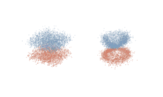

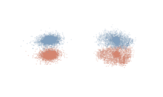

In [41]:
# Create 3D visualization
fig_2c_pred = visualize_3d_projections(
    projections_data=pred_projections_list[0],
    labels_data=pred_latent_labels_list[0],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (3, 4, r'$\hat{v}_x$', r'$\hat{v}_y$', r'$\hat{S}$'),  # velocity pair
        (6, 7, r'$\hat{\sin\theta}$', r'$\hat{\cos\theta}$', r'$\hat{S}$')  # orientation pair
    ],
    figsize=(2, 1),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
    z_amp_factor=2.0,  # Adjust z-axis amplitude factor for better visibility
)

fig_2c_inv = visualize_3d_projections(
    projections_data=inv_projections_list[0],
    labels_data=inv_latent_labels_list[0],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (3, 4, r'$\hat{v}_x$', r'$\hat{v}_y$', r'$\hat{S}$'),  # velocity pair
        (6, 7, r'$\hat{\sin\theta}$', r'$\hat{\cos\theta}$', r'$\hat{S}$')  # orientation pair
    ],
    figsize=(2, 1),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
)

# save the figure
fig_2c_pred.savefig(os.path.join(savedir, 'pred_regressor_3d.png'), dpi=300, bbox_inches='tight', transparent=True)
fig_2c_inv.savefig(os.path.join(savedir, 'inv_regressor_3d.png'), dpi=300, bbox_inches='tight', transparent=True)

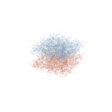

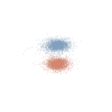

In [ ]:
# Create 3D visualization
fig_2c_pred = visualize_3d_projections(
    projections_data=pred_projections_list[0],
    labels_data=pred_latent_labels_list[0],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (3, 4, r'$\hat{v}_x$', r'$\hat{v}_y$', r'$\hat{S}$'),  # velocity pair
    ],
    figsize=(2, 1.2),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
    z_amp_factor=2.0,  # Adjust z-axis amplitude factor for better visibility
)

fig_2c_inv = visualize_3d_projections(
    projections_data=inv_projections_list[0],
    labels_data=inv_latent_labels_list[0],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (3, 4, r'$\hat{v}_x$', r'$\hat{v}_y$', r'$\hat{S}$'),  # velocity pair
    ],
    figsize=(2, 1.2),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
)

# save the figure
fig_2c_pred.savefig(os.path.join(savedir, 'pred_regressor_3d_vel.png'), dpi=300, bbox_inches='tight', transparent=True)
fig_2c_inv.savefig(os.path.join(savedir, 'inv_regressor_3d_vel.png'), dpi=300, bbox_inches='tight', transparent=True)

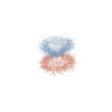

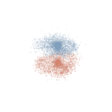

In [ ]:
# Create 3D visualization
fig_2c_pred = visualize_3d_projections(
    projections_data=pred_projections_list[0],
    labels_data=pred_latent_labels_list[0],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (6, 7, r'$\hat{\sin\theta}$', r'$\hat{\cos\theta}$', r'$\hat{S}$')  # orientation pair
    ],
    figsize=(2, 1.2),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
    z_amp_factor=2.0,  # Adjust z-axis amplitude factor for better visibility
)

fig_2c_inv = visualize_3d_projections(
    projections_data=inv_projections_list[0],
    labels_data=inv_latent_labels_list[0],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (6, 7, r'$\hat{\sin\theta}$', r'$\hat{\cos\theta}$', r'$\hat{S}$')  # orientation pair
    ],
    figsize=(2, 1.2),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
)

# save the figure
fig_2c_pred.savefig(os.path.join(savedir, 'pred_regressor_3d_theta.png'), dpi=300, bbox_inches='tight', transparent=True)
fig_2c_inv.savefig(os.path.join(savedir, 'inv_regressor_3d_theta.png'), dpi=300, bbox_inches='tight', transparent=True)

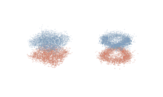

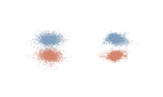

In [48]:
# Create 3D visualization
fig_2c_pred = visualize_3d_projections(
    projections_data=pred_projections_list[1],
    labels_data=pred_latent_labels_list[1],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (3, 4, r'$\hat{v}_x$', r'$\hat{v}_y$', r'$\hat{S}$'),  # velocity pair
        (6, 7, r'$\hat{\sin\theta}$', r'$\hat{\cos\theta}$', r'$\hat{S}$')  # orientation pair
    ],
    figsize=(2, 1),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
    z_amp_factor=2.0,  # Adjust z-axis amplitude factor for better visibility
)

fig_2c_inv = visualize_3d_projections(
    projections_data=inv_projections_list[1],
    labels_data=inv_latent_labels_list[1],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (3, 4, r'$\hat{v}_x$', r'$\hat{v}_y$', r'$\hat{S}$'),  # velocity pair
        (6, 7, r'$\hat{\sin\theta}$', r'$\hat{\cos\theta}$', r'$\hat{S}$')  # orientation pair
    ],
    figsize=(2, 1),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
)

# save the figure
fig_2c_pred.savefig(os.path.join(savedir, 'pred_regressor_3d_1.png'), dpi=300, bbox_inches='tight', transparent=True)
fig_2c_inv.savefig(os.path.join(savedir, 'inv_regressor_3d_1.png'), dpi=300, bbox_inches='tight', transparent=True)

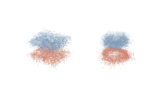

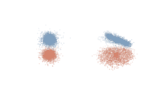

In [49]:
# Create 3D visualization
fig_2c_pred = visualize_3d_projections(
    projections_data=pred_projections_list[-1],
    labels_data=pred_latent_labels_list[-1],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (3, 4, r'$\hat{v}_x$', r'$\hat{v}_y$', r'$\hat{S}$'),  # velocity pair
        (6, 7, r'$\hat{\sin\theta}$', r'$\hat{\cos\theta}$', r'$\hat{S}$')  # orientation pair
    ],
    figsize=(2, 1),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
    z_amp_factor=2.0,  # Adjust z-axis amplitude factor for better visibility
)

fig_2c_inv = visualize_3d_projections(
    projections_data=inv_projections_list[-1],
    labels_data=inv_latent_labels_list[-1],
    class_colors={0: '#d4856f', 1: '#81a0be'},  # Colors for classes 0 and 1
    paired_vars=[
        (3, 4, r'$\hat{v}_x$', r'$\hat{v}_y$', r'$\hat{S}$'),  # velocity pair
        (6, 7, r'$\hat{\sin\theta}$', r'$\hat{\cos\theta}$', r'$\hat{S}$')  # orientation pair
    ],
    figsize=(2, 1),
    elevation=30,
    azimuth=30,
    point_size=1,
    point_alpha=0.2,
    n_samples=5000,
)

# save the figure
fig_2c_pred.savefig(os.path.join(savedir, 'pred_regressor_3d_2.png'), dpi=300, bbox_inches='tight', transparent=True)
fig_2c_inv.savefig(os.path.join(savedir, 'inv_regressor_3d_2.png'), dpi=300, bbox_inches='tight', transparent=True)

In [37]:
# get middle color from colormap
def get_middle_color(cmap_name, num_colors=256):
    cmap = plt.get_cmap(cmap_name, num_colors)
    middle_index = num_colors // 2
    return cmap(middle_index)

# get three colors from colormap
def get_three_colors(cmap_name, num_colors=256):
    cmap = plt.get_cmap(cmap_name, num_colors)
    indices = [0, num_colors // 2, num_colors - 1]
    return [cmap(i) for i in indices]

mid_color = get_middle_color(colormap)

three_colors = get_three_colors(cm.lajolla)

In [38]:
# print hex code from the rgba color
def rgba_to_hex(rgba):
    return '#{:02x}{:02x}{:02x}'.format(
        int(rgba[0] * 255),
        int(rgba[1] * 255),
        int(rgba[2] * 255),
    )
three_colors_hex = [rgba_to_hex(color) for color in three_colors]
print(three_colors_hex)

['#191900', '#d9604d', '#fffeca']


In [ ]:
fig_sin_pred, ax_sin_pred = plot_sin_cos_vs_theta(
    projections_data=pred_projections_list[0],
    labels_data=pred_latent_labels_list[0],
    trig_function='sin',
    prediction_color=mid_color,
    show_xlabel=True,
    use_corrected_orientation=True,
    show_metrics=False,
    n_samples=1000
)

fig_sin_inv, ax_sin_inv = plot_sin_cos_vs_theta(
    projections_data=inv_projections_list[0],
    labels_data=inv_latent_labels_list[0],
    trig_function='sin',
    prediction_color="#888888",
    show_xlabel=True,
    show_ylabel=True,
    use_corrected_orientation=True,
    show_metrics=False,
    n_samples=1000
)

# Save the figures
fig_sin_pred.savefig(os.path.join(savedir, 'predicted_sin_vs_corrected_theta_pred.png'), dpi=300, bbox_inches='tight', transparent=True)
fig_sin_inv.savefig(os.path.join(savedir, 'predicted_sin_vs_corrected_theta_inv.png'), dpi=300, bbox_inches='tight', transparent=True)

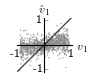

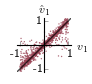

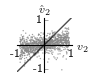

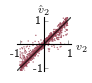

(<Figure size 70x70 with 1 Axes>,
 <Axes: xlabel='$v_2$', ylabel='$\\hat{v}_2$'>)

In [40]:
label_names = [r'$\hat{x}$', r'$\hat{y}$', r'$\hat{z}$', r'$\hat{v_x}$', r'$\hat{v_y}$', r'$\hat{v_z}$', r'$\widehat{\sin\theta}$', r'$\widehat{\cos\theta}$']

plot_variable_vs_true(inv_projections_list[0][3]["x-velocity"], inv_latent_labels_list[0][3]["x-velocity"], 'vx', n_samples=1000, save_path=os.path.join(savedir, 'inv_vx_vs_true.png'), show_ylabel=True, color="#888888")
plot_variable_vs_true(pred_projections_list[0][3]["x-velocity"], inv_latent_labels_list[0][3]["x-velocity"], 'vx', n_samples=1000, save_path=os.path.join(savedir, 'pred_vx_vs_true.png'))

plot_variable_vs_true(inv_projections_list[0][3]["y-velocity"], inv_latent_labels_list[0][3]["y-velocity"], 'vy', n_samples=1000, save_path=os.path.join(savedir, 'inv_vy_vs_true.png'), show_ylabel=True, color="#888888")
plot_variable_vs_true(pred_projections_list[0][3]["y-velocity"], inv_latent_labels_list[0][3]["y-velocity"], 'vy', n_samples=1000, save_path=os.path.join(savedir, 'pred_vy_vs_true.png'))